# I will recreat the model that they use to predict the "score text" to see whe the bias is

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cox_filt = pd.read_csv("../../data/cox-violent-parsed_filt.csv")
cox_filt.head()

,id,name,first,last,sex,dob,age,age_cat,race,juv_fel_count,...,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,priors_count.1,event
0,1.0,miguel hernandez,miguel,hernandez,Male,18/04/1947,69,Greater than 45,Other,0,...,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,0,0
1,2.0,miguel hernandez,miguel,hernandez,Male,18/04/1947,69,Greater than 45,Other,0,...,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,0,0
2,3.0,michael ryan,michael,ryan,Male,06/02/1985,31,25 - 45,Caucasian,0,...,NaN,Risk of Recidivism,5,Medium,31/12/2014,Risk of Violence,2,Low,0,0
3,4.0,kevon dixon,kevon,dixon,Male,22/01/1982,34,25 - 45,African-American,0,...,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,27/01/2013,Risk of Violence,1,Low,0,1
4,5.0,ed philo,ed,philo,Male,14/05/1991,24,Less than 25,African-American,0,...,NaN,Risk of Recidivism,4,Low,14/04/2013,Risk of Violence,3,Low,4,0


In [3]:
print(cox_filt.shape)
cox_filt.describe()

(18316, 40)


,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,event
count,11001.00000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,17019.000000,17449.000000,18316.000000,6359.000000,0.0,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000
mean,5501.00000,34.019273,0.076873,4.997052,0.098439,0.124263,3.913191,4.302485,57.694596,0.414774,19.961629,NaN,0.073105,4.997052,4.022822,3.913191,0.044715
std,3175.85949,11.667811,0.464272,2.937569,0.517639,0.524537,5.299864,81.159881,317.994694,0.576449,74.139695,NaN,0.260317,2.937569,2.614189,5.299864,0.206683
min,1.00000,18.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,-597.000000,0.000000,-1.000000,-1.000000,NaN,0.000000,-1.000000,-1.000000,0.000000,0.000000
25%,2751.00000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,2.000000,0.000000,0.000000
50%,5501.00000,31.000000,0.000000,5.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,5.000000,4.000000,2.000000,0.000000
75%,8251.00000,41.000000,0.000000,8.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,1.000000,NaN,0.000000,8.000000,6.000000,5.000000,0.000000
max,11001.00000,96.000000,20.000000,10.000000,13.000000,17.000000,43.000000,1057.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,43.000000,1.000000


In [4]:
cox_filt.notnull().sum()

id                         11001
name                       18316
first                      18316
last                       18316
sex                        18316
dob                        18316
age                        18316
age_cat                    18316
race                       18316
juv_fel_count              18316
decile_score               18316
juv_misd_count             18316
juv_other_count            18316
priors_count               18316
days_b_screening_arrest    17019
c_jail_in                  17019
c_jail_out                 17019
c_days_from_compas         17449
c_charge_degree            17449
c_charge_desc              17435
is_recid                   18316
r_charge_degree             8417
r_days_from_arrest          6359
r_offense_date              8417
r_charge_desc               8277
r_jail_in                   6359
violent_recid                  0
is_violent_recid           18316
vr_charge_degree            1339
vr_offense_date             1339
vr_charge_

In [5]:
# List of the columns that are not null at 50% or more
cox_filt.notnull().sum()[cox_filt.notnull().sum() < len(cox_filt) * 0.5].index.tolist()

['r_charge_degree',
 'r_days_from_arrest',
 'r_offense_date',
 'r_charge_desc',
 'r_jail_in',
 'violent_recid',
 'vr_charge_degree',
 'vr_offense_date',
 'vr_charge_desc']

In [6]:
# Delete all the columns that are null at 50% or more
cox_filt = cox_filt.dropna(thresh=len(cox_filt) * 0.5, axis=1)
print(cox_filt.columns)
cox_filt.shape

Index(['id', 'name', 'first', 'last', 'sex', 'dob', 'age', 'age_cat', 'race',
       'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count',
       'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out',
       'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid',
       'is_violent_recid', 'type_of_assessment', 'decile_score.1',
       'score_text', 'screening_date', 'v_type_of_assessment',
       'v_decile_score', 'v_score_text', 'priors_count.1', 'event'],
      dtype='object')


(18316, 31)

In [7]:
cox_filt.dtypes

id                         float64
name                        object
first                       object
last                        object
sex                         object
dob                         object
age                          int64
age_cat                     object
race                        object
juv_fel_count                int64
decile_score                 int64
juv_misd_count               int64
juv_other_count              int64
priors_count                 int64
days_b_screening_arrest    float64
c_jail_in                   object
c_jail_out                  object
c_days_from_compas         float64
c_charge_degree             object
c_charge_desc               object
is_recid                     int64
is_violent_recid             int64
type_of_assessment          object
decile_score.1               int64
score_text                  object
screening_date              object
v_type_of_assessment        object
v_decile_score               int64
v_score_text        

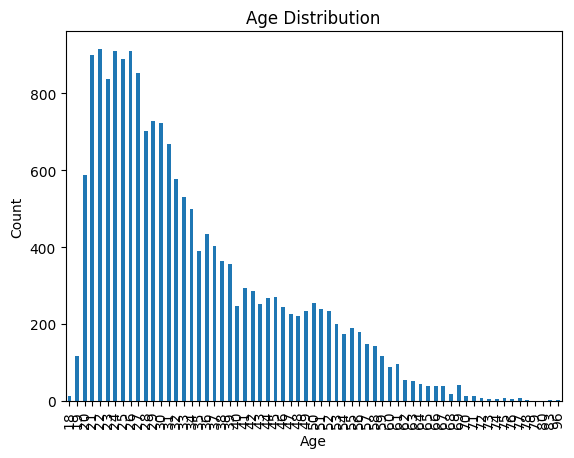

In [8]:
cox_filt['age'].value_counts().sort_index().plot(kind='bar')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

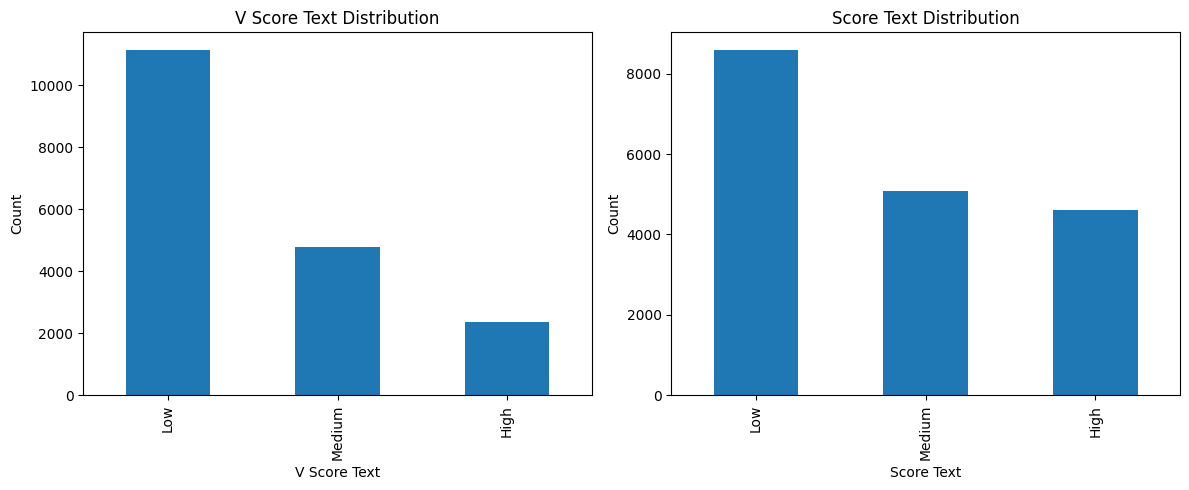

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Define the order
order = ["Low", "Medium", "High"]

# Plot v_score_text with custom order
v_counts = cox_filt['v_score_text'].value_counts()
v_counts = v_counts.reindex(order)
v_counts.plot(kind='bar', ax=ax1)
ax1.set_title("V Score Text Distribution")
ax1.set_xlabel("V Score Text")
ax1.set_ylabel("Count")

# Plot score_text with custom order
s_counts = cox_filt['score_text'].value_counts()
s_counts = s_counts.reindex(order)
s_counts.plot(kind='bar', ax=ax2)
ax2.set_title("Score Text Distribution")
ax2.set_xlabel("Score Text")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [10]:
# remove all the columns that have score in the name and put them in another dataframe
cox_score = cox_filt.filter(like='score')
print(cox_score.columns)

# remove all the columns that have score in the name
cox_filt = cox_filt.drop(columns=cox_score.columns)
print(cox_filt.columns)

Index(['decile_score', 'decile_score.1', 'score_text', 'v_decile_score',
       'v_score_text'],
      dtype='object')
Index(['id', 'name', 'first', 'last', 'sex', 'dob', 'age', 'age_cat', 'race',
       'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out',
       'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid',
       'is_violent_recid', 'type_of_assessment', 'screening_date',
       'v_type_of_assessment', 'priors_count.1', 'event'],
      dtype='object')


In [11]:
# Remove personal identifiers
cox_filt = cox_filt.drop(columns=['id', 'name', 'first', 'last', 'dob', 'age_cat'])
cox_filt.columns

Index(['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'days_b_screening_arrest',
       'c_jail_in', 'c_jail_out', 'c_days_from_compas', 'c_charge_degree',
       'c_charge_desc', 'is_recid', 'is_violent_recid', 'type_of_assessment',
       'screening_date', 'v_type_of_assessment', 'priors_count.1', 'event'],
      dtype='object')

In [12]:
# Value counts for categorical columns
for col in cox_filt.select_dtypes(include=['object']).columns:
    print(f"{col} value counts:")
    print(cox_filt[col].value_counts())
    print("\n")

sex value counts:
sex
Male      14933
Female     3383
Name: count, dtype: int64


race value counts:
race
African-American    9791
Caucasian           6086
Hispanic            1451
Other                860
Asian                 71
Native American       57
Name: count, dtype: int64


c_jail_in value counts:
c_jail_in
09/04/2013 9:14     13
04/02/2013 7:24     13
27/04/2014 11:04    12
24/03/2013 2:25     11
14/05/2013 9:51     11
                    ..
27/12/2013 9:29      1
30/05/2014 8:40      1
19/12/2014 4:46      1
05/09/2013 5:04      1
26/02/2014 10:21     1
Name: count, Length: 9806, dtype: int64


c_jail_out value counts:
c_jail_out
30/04/2013 7:29     19
02/04/2013 12:50    15
18/04/2013 6:22     13
15/03/2013 8:19     13
12/02/2013 8:09     13
                    ..
20/12/2014 8:52      1
24/03/2014 9:09      1
09/10/2013 2:16      1
31/07/2014 8:33      1
26/11/2013 8:26      1
Name: count, Length: 8714, dtype: int64


c_charge_degree value counts:
c_charge_degree
(F3)     1

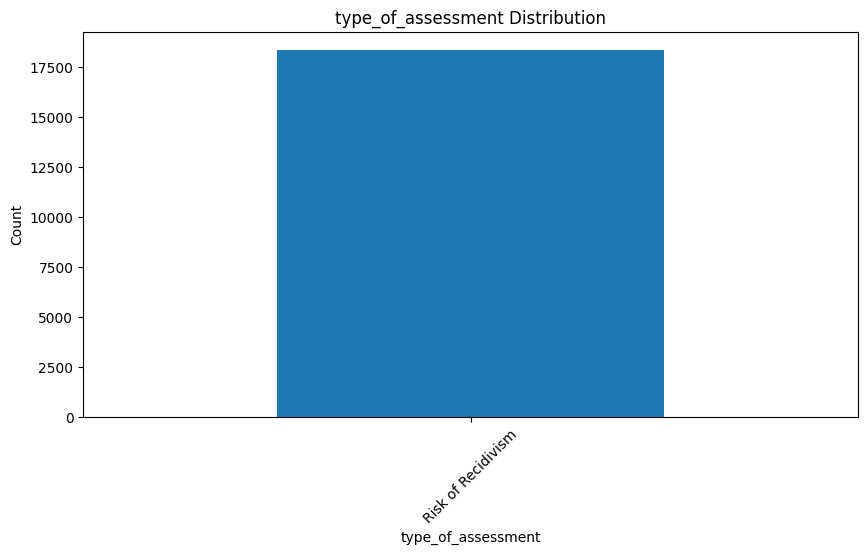

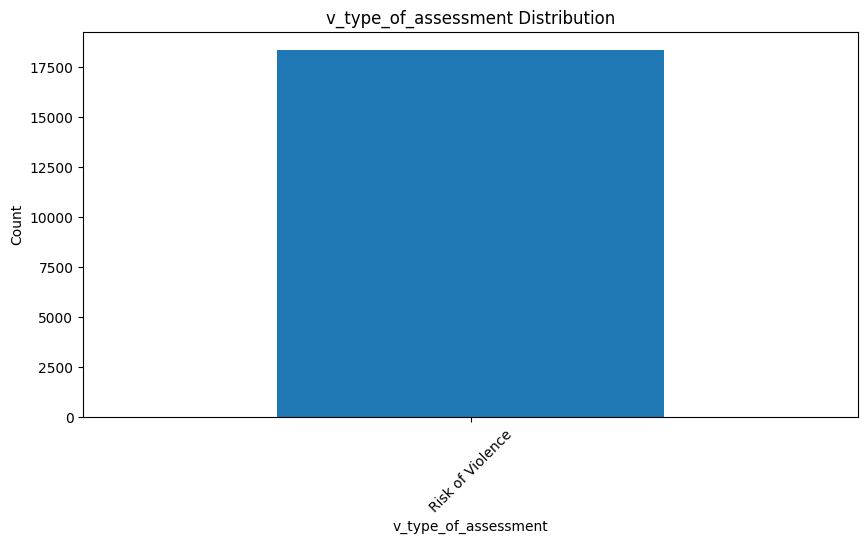

In [13]:
# Plot when type_of_assessment is in the columns name
for col in cox_filt.columns:
    if 'type_of_assessment' in col:
        plt.figure(figsize=(10, 5))
        cox_filt[col].value_counts().plot(kind='bar')
        plt.title(f"{col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

We can drop those too

In [14]:
# Drop when  type_of_assessment is in the columns name
cox_filt = cox_filt.drop(columns=[col for col in cox_filt.columns if 'type_of_assessment' in col])
print(cox_filt.columns)

Index(['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'days_b_screening_arrest',
       'c_jail_in', 'c_jail_out', 'c_days_from_compas', 'c_charge_degree',
       'c_charge_desc', 'is_recid', 'is_violent_recid', 'screening_date',
       'priors_count.1', 'event'],
      dtype='object')


In [15]:
# Removing also the columns "is_violent_recid"
cox_filt = cox_filt.drop(columns=['is_violent_recid'])
print(cox_filt.columns)

Index(['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'days_b_screening_arrest',
       'c_jail_in', 'c_jail_out', 'c_days_from_compas', 'c_charge_degree',
       'c_charge_desc', 'is_recid', 'screening_date', 'priors_count.1',
       'event'],
      dtype='object')


In [16]:
# Calculate the number of days between c_jail_in and c_jail_out
cox_filt['c_jail_in'] = pd.to_datetime(cox_filt['c_jail_in'], errors='coerce')
cox_filt['c_jail_out'] = pd.to_datetime(cox_filt['c_jail_out'], errors='coerce')

cox_filt['days_in_jail'] = (cox_filt['c_jail_out'] - cox_filt['c_jail_in']).dt.days

# Drop the original date columns
cox_filt = cox_filt.drop(columns=['c_jail_in', 'c_jail_out', 'c_days_from_compas', 'days_b_screening_arrest', 'screening_date']) 
print(cox_filt.columns)

Index(['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'c_charge_degree', 'c_charge_desc',
       'is_recid', 'priors_count.1', 'event', 'days_in_jail'],
      dtype='object')


C:\Users\tanjo\AppData\Local\Temp\ipykernel_298212\3906192732.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cox_filt['c_jail_in'] = pd.to_datetime(cox_filt['c_jail_in'], errors='coerce')
C:\Users\tanjo\AppData\Local\Temp\ipykernel_298212\3906192732.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cox_filt['c_jail_out'] = pd.to_datetime(cox_filt['c_jail_out'], errors='coerce')


In [17]:
# Dealing with the dates
cox_filt.notnull().sum()

sex                18316
age                18316
race               18316
juv_fel_count      18316
juv_misd_count     18316
juv_other_count    18316
priors_count       18316
c_charge_degree    17449
c_charge_desc      17435
is_recid           18316
priors_count.1     18316
event              18316
days_in_jail       17019
dtype: int64

In [18]:
cox_filt.head()

,sex,age,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,c_charge_desc,is_recid,priors_count.1,event,days_in_jail
0,Male,69,Other,0,0,0,0,(F3),Aggravated Assault w/Firearm,0,0,0,0.0
1,Male,69,Other,0,0,0,0,(F3),Aggravated Assault w/Firearm,0,0,0,0.0
2,Male,31,Caucasian,0,0,0,0,NaN,NaN,-1,0,0,NaN
3,Male,34,African-American,0,0,0,0,(F3),Felony Battery w/Prior Convict,1,0,1,10.0
4,Male,24,African-American,0,0,1,4,(F3),Possession of Cocaine,1,4,0,1.0


In [19]:
# Fill the missing values mean for numerical columns and mode for categorical columns
for col in cox_filt.select_dtypes(include=['float64', 'int64']).columns:
    cox_filt[col].fillna(cox_filt[col].mean(), inplace=True)

for col in cox_filt.select_dtypes(include=['object']).columns:
    cox_filt[col].fillna(cox_filt[col].mode()[0], inplace=True)


cox_filt.notnull().sum()

C:\Users\tanjo\AppData\Local\Temp\ipykernel_298212\762581847.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cox_filt[col].fillna(cox_filt[col].mean(), inplace=True)
C:\Users\tanjo\AppData\Local\Temp\ipykernel_298212\762581847.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


sex                18316
age                18316
race               18316
juv_fel_count      18316
juv_misd_count     18316
juv_other_count    18316
priors_count       18316
c_charge_degree    18316
c_charge_desc      18316
is_recid           18316
priors_count.1     18316
event              18316
days_in_jail       18316
dtype: int64

In [20]:
# Encoding categorical variables in cox_filt
cox_filt = pd.get_dummies(cox_filt, drop_first=True)
cox_filt.head()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,is_recid,priors_count.1,event,days_in_jail,sex_Male,...,c_charge_desc_Viol Injunct Domestic Violence,c_charge_desc_Viol Injunction Protect Dom Vi,c_charge_desc_Viol Pretrial Release Dom Viol,c_charge_desc_Viol Prot Injunc Repeat Viol,c_charge_desc_Violation License Restrictions,c_charge_desc_Violation Of Boater Safety Id,c_charge_desc_Violation of Injunction Order/Stalking/Cyberstalking,c_charge_desc_Voyeurism,c_charge_desc_Workers Compensation Fraud,c_charge_desc_arrest case no charge
0,69,0,0,0,0,0,0,0,0.000000,True,...,False,False,False,False,False,False,False,False,False,False
1,69,0,0,0,0,0,0,0,0.000000,True,...,False,False,False,False,False,False,False,False,False,False
2,31,0,0,0,0,-1,0,0,25.019096,True,...,False,False,False,False,False,False,False,False,False,True
3,34,0,0,0,0,1,0,1,10.000000,True,...,False,False,False,False,False,False,False,False,False,False
4,24,0,0,1,4,1,4,0,1.000000,True,...,False,False,False,False,False,False,False,False,False,False


In [25]:
# fill missing values in cox_score mean for numerical columns and mode for categorical columns
for col in cox_score.select_dtypes(include=['float64', 'int64']).columns:
    cox_score[col].fillna(cox_score[col].mean(), inplace=True)

for col in cox_score.select_dtypes(include=['object']).columns:
    cox_score[col].fillna(cox_score[col].mode()[0], inplace=True)

cox_score.notnull().sum()

C:\Users\tanjo\AppData\Local\Temp\ipykernel_298212\4049441295.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cox_score[col].fillna(cox_score[col].mean(), inplace=True)


decile_score      18316
decile_score.1    18316
score_text        18316
v_decile_score    18316
v_score_text      18316
dtype: int64

In [26]:
# Change the categorical columns to numerical columns
cox_score['score_text'].replace({'Low': 0, 'Medium': 1, 'High': 2}, inplace=True)
cox_score['v_score_text'].replace({'Low': 0, 'Medium': 1, 'High': 2}, inplace=True)
cox_score.head()

,decile_score,decile_score.1,score_text,v_decile_score,v_score_text
0,1,1,0,1,0
1,1,1,0,1,0
2,5,5,1,2,0
3,3,3,0,1,0
4,4,4,0,3,0


# Model

In [27]:
# Random forest model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [28]:
# I will recreate the model that they use to predict the "score text" to see where the bias is
X = cox_filt
y = cox_score['score_text']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create a random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
# Predict on the test set
y_pred = rf.predict(X_test)
# Evaluate the model
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1710
           1       0.82      0.75      0.78      1007
           2       0.85      0.87      0.86       947

    accuracy                           0.85      3664
   macro avg       0.85      0.84      0.84      3664
weighted avg       0.85      0.85      0.85      3664

Accuracy: 0.8501637554585153


# Explicability

In [29]:
import shap

c:\Users\tanjo\projetcs\sesame-shap\sesame\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Use SHAP to explain the model
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)